### Instrucción 1
Cargar foto de rostro. Nombre de imagen 'whatdafunk.jpg'

Image shape: (601, 601, 3)
Image data type: uint8


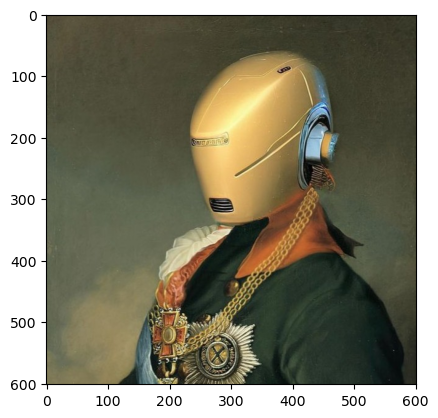

In [67]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('whatdafunk.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
if img is None:
    print("Error: Could not open or find the image.")
else:
    print(f"Image shape: {img.shape}")
    print(f"Image data type: {img.dtype}")
    plt.imshow(img)
    plt.show()

### Instrucción 2
- Separe los canales de la imagen RGB (paso 1) a tres variables con sus respectivos canales (R, G, B). 
- Almacene el resultado de dichas imágenes en diferentes archivos independientes (tip: investigue sobre el comando imwrite() en OpenCV)

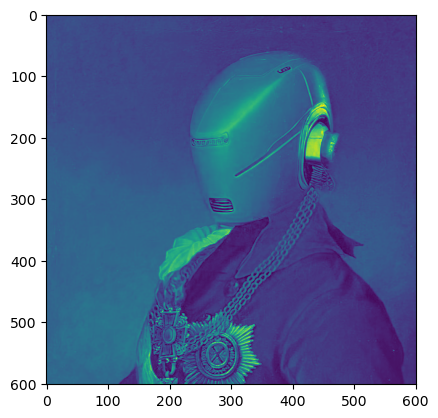

In [68]:
B, G, R = cv2.split(img)
plt.imshow(R)
plt.show()

In [69]:
# Guardar los canales separados en archivos independientes
cv2.imwrite('R.jpg', R)
cv2.imwrite('G.jpg', G)
cv2.imwrite('B.jpg', B)

print("Los canales se han guardado como imágenes independientes.")

Los canales se han guardado como imágenes independientes.


### Instrucción 3
- Transforme la imagen a niveles de gris empleando la función de transformación (cv2.COLOR_BGR2GRAY). 
- Despliegue la imagen por el browser y compare esta imagen con cada uno de los canales R, G y B del paso 2. Para ello calcule la imagen diferencia. 
- Despliege el resultado por el browser o una ventana.

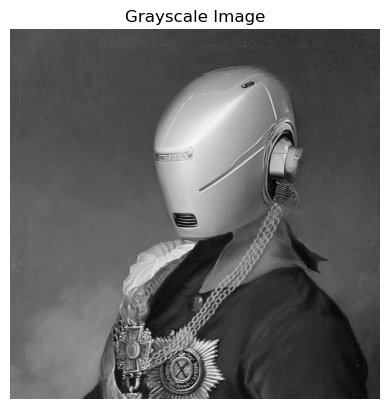

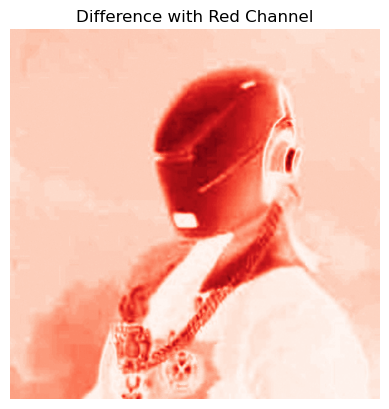

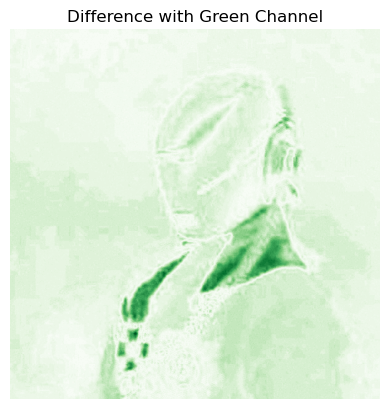

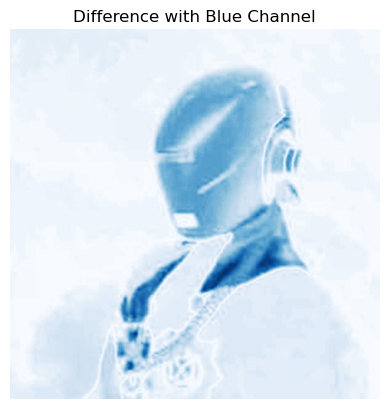

In [70]:
# Convert the RGB image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Display the grayscale image
plt.imshow(gray_img, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')  # Hide the axis
plt.show()
R = cv2.imread('R.jpg')
G = cv2.imread('G.jpg')
B = cv2.imread('B.jpg')
if R is None or G is None or B is None:
    print("Error: Could not open or find some image.")
else:
    diff_R = cv2.absdiff(gray_img, R[:, :, 0])
    diff_G = cv2.absdiff(gray_img, G[:, :, 0])
    diff_B = cv2.absdiff(gray_img, B[:, :, 0])

    # Normalize the differences to ensure values are between 0 and 255
    diff_R = cv2.normalize(diff_R, None, 0, 255, cv2.NORM_MINMAX)
    diff_G = cv2.normalize(diff_G, None, 0, 255, cv2.NORM_MINMAX)
    diff_B = cv2.normalize(diff_B, None, 0, 255, cv2.NORM_MINMAX)

    # Display the differences
    plt.imshow(diff_R, cmap='Reds')
    plt.title('Difference with Red Channel')
    plt.axis('off')
    plt.figure()
    plt.imshow(diff_G, cmap='Greens')
    plt.title('Difference with Green Channel')
    plt.axis('off')
    plt.figure()
    plt.imshow(diff_B, cmap='Blues')
    plt.title('Difference with Blue Channel')
    plt.axis('off')
    

plt.show()

### Instrucción 4
Ecualice los histogramas de los canales R, G y B, obtenidos en el paso 2 según el algoritmo
visto en clases y muestre el resultado por el browser con el resultado de cada ecualización.


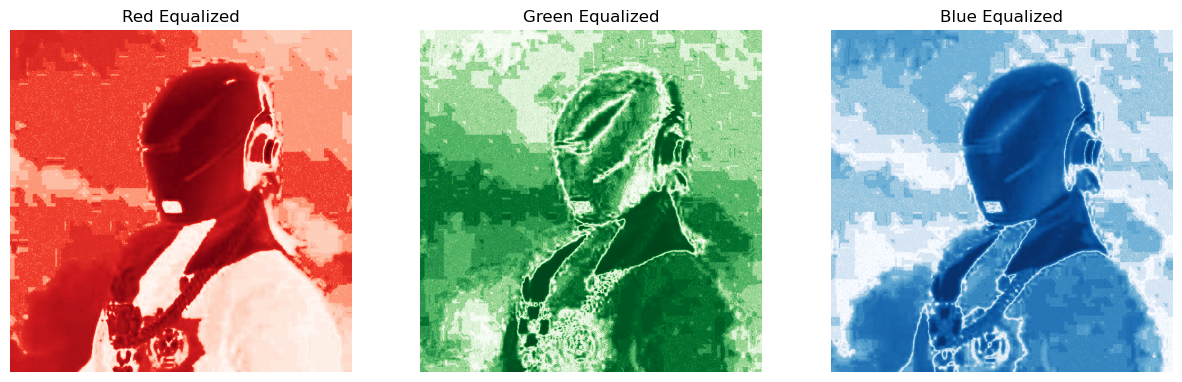

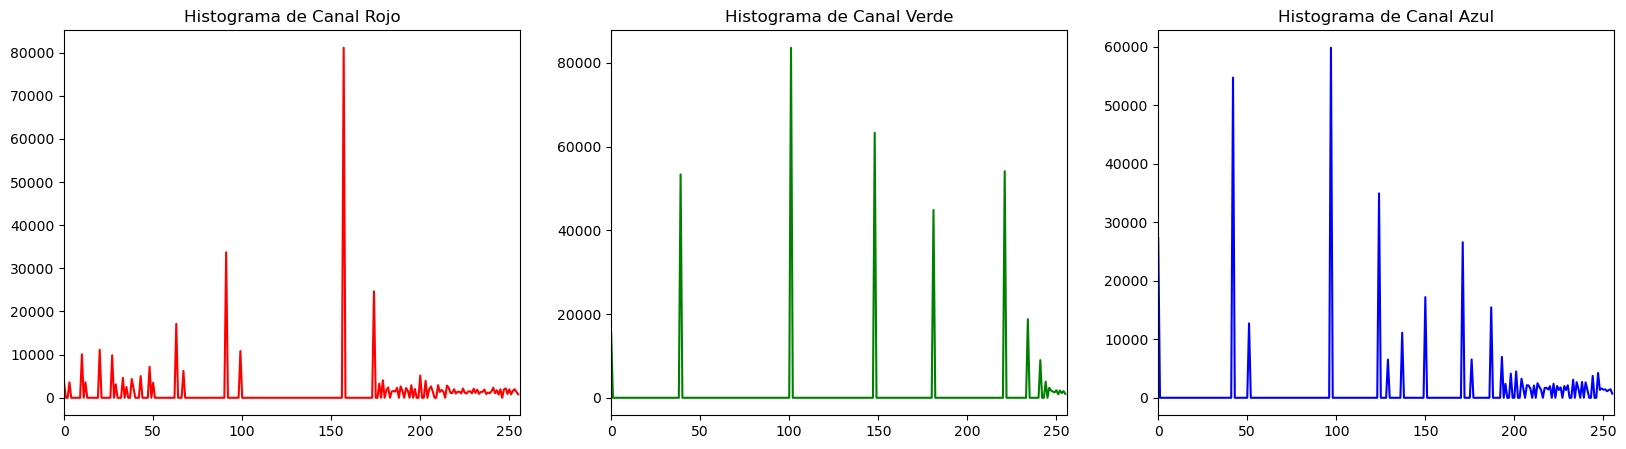

In [71]:
import numpy as np

# Ecualizar el histograma de una imagen en escala de grises
EQR_hulk = cv2.equalizeHist(diff_R)
EQG_hulk = cv2.equalizeHist(diff_G)
EQB_hulk = cv2.equalizeHist(diff_B)

plt.figure(figsize=(15, 5))

# Red Equalized
plt.subplot(1, 3, 1)
plt.imshow(EQR_hulk, cmap='Reds')
plt.title('Red Equalized')
plt.axis('off')

# Green Equalized
plt.subplot(1, 3, 2)
plt.imshow(EQG_hulk, cmap='Greens')
plt.title('Green Equalized')
plt.axis('off')

# Blue Equalized
plt.subplot(1, 3, 3)
plt.imshow(EQB_hulk, cmap='Blues')
plt.title('Blue Equalized')
plt.axis('off')
plt.show()

hist_red = cv2.calcHist([EQR_hulk], [0], None, [256], [0, 256])
hist_green = cv2.calcHist([EQG_hulk], [0], None, [256], [0, 256])
hist_blue = cv2.calcHist([EQB_hulk], [0], None, [256], [0, 256])

plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
plt.plot(hist_red, color='red')
plt.xlim([0, 256])
plt.title('Histograma de Canal Rojo')

plt.subplot(1, 3, 2)
plt.plot(hist_green, color='green')
plt.xlim([0, 256])
plt.title('Histograma de Canal Verde')

plt.subplot(1, 3, 3)
plt.plot(hist_blue, color='blue')
plt.xlim([0, 256])
plt.title('Histograma de Canal Azul')

plt.show()





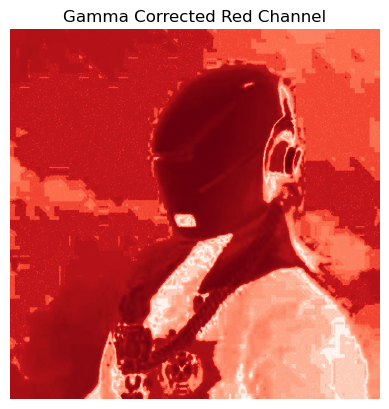

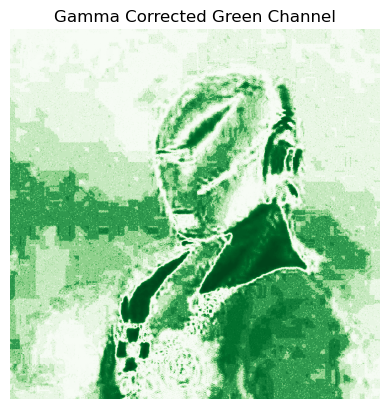

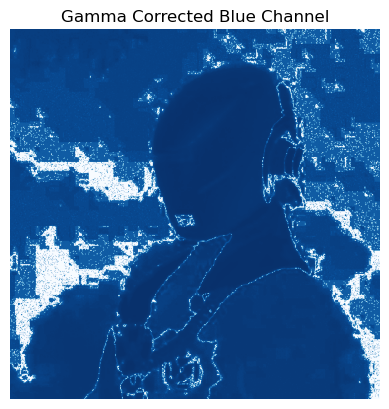

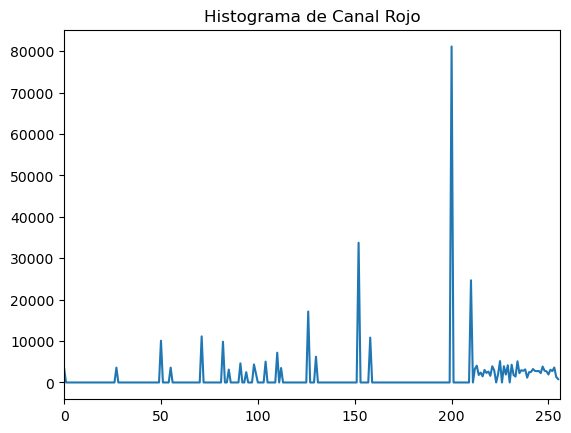

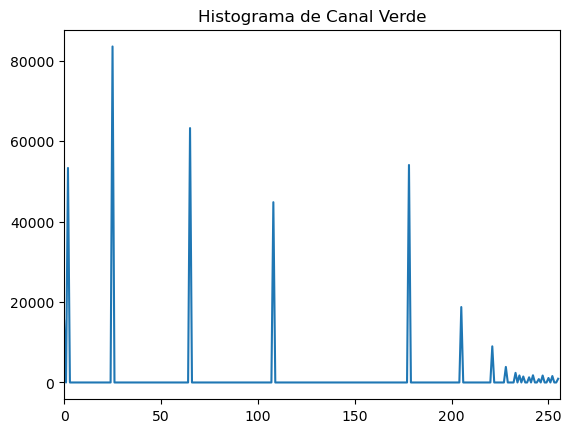

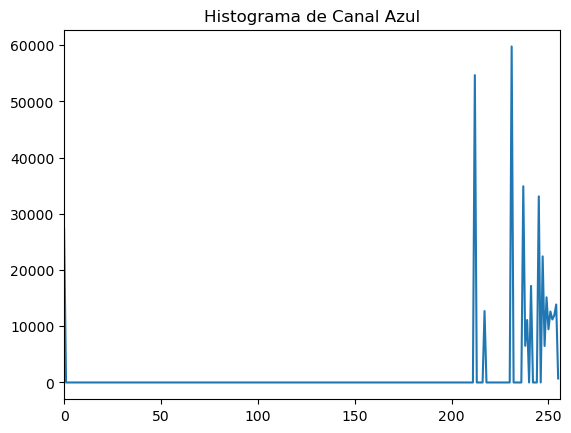

In [72]:
import numpy as np

def gamma_correction(img, factor):
    img = img/255.0
    img = cv2.pow(img, factor)
    return np.uint8(img*255)


# Apply gamma correction with a factor of 2.0
Red_Hulk = gamma_correction(EQR_hulk, 0.5)

Green_Hulk = gamma_correction(EQG_hulk, 2.5)

Blue_Hulk = gamma_correction(EQB_hulk, 0.1)

# Display the gamma corrected images
plt.imshow(Red_Hulk, cmap='Reds')
plt.title('Gamma Corrected Red Channel')
plt.axis('off')

plt.show()


plt.imshow(Green_Hulk, cmap='Greens')
plt.title('Gamma Corrected Green Channel')
plt.axis('off')
plt.show()

plt.imshow(Blue_Hulk, cmap='Blues')
plt.title('Gamma Corrected Blue Channel')
plt.axis('off')
plt.show()

hist_red = cv2.calcHist([Red_Hulk], [0], None, [256], [0, 256])
hist_green = cv2.calcHist([Green_Hulk], [0], None, [256], [0, 256])
hist_blue = cv2.calcHist([Blue_Hulk], [0], None, [256], [0, 256])

plt.plot(hist_red)
plt.xlim([0,256])
plt.title('Histograma de Canal Rojo')
plt.show()
plt.plot(hist_green)
plt.xlim([0,256])
plt.title('Histograma de Canal Verde')
plt.show()
plt.plot(hist_blue)
plt.xlim([0,256])
plt.title('Histograma de Canal Azul')
plt.show()









### Instrucción 7
Reconstruya la imagen a color (con sus tres canales) a partir de los resultados previos. 
Para ello: 
- Utilice el comando cv2_merge(). 
- Realice las siguientes reconstrucciones:
    - Imagen #1: [ R_original, G_gamma_2.5, B_ecualizado ]
    - Imagen #2: [ R_gamma_0.5, G_ecualizado, B_original ]
    - Imagen #3: [ R_ecualizado, G_original, B_gamma_0.1]
- Muestre ambos resultados por el browser. 
> Observación: R_original, B_original, y G_original son los canales obtenidos en el paso 3.

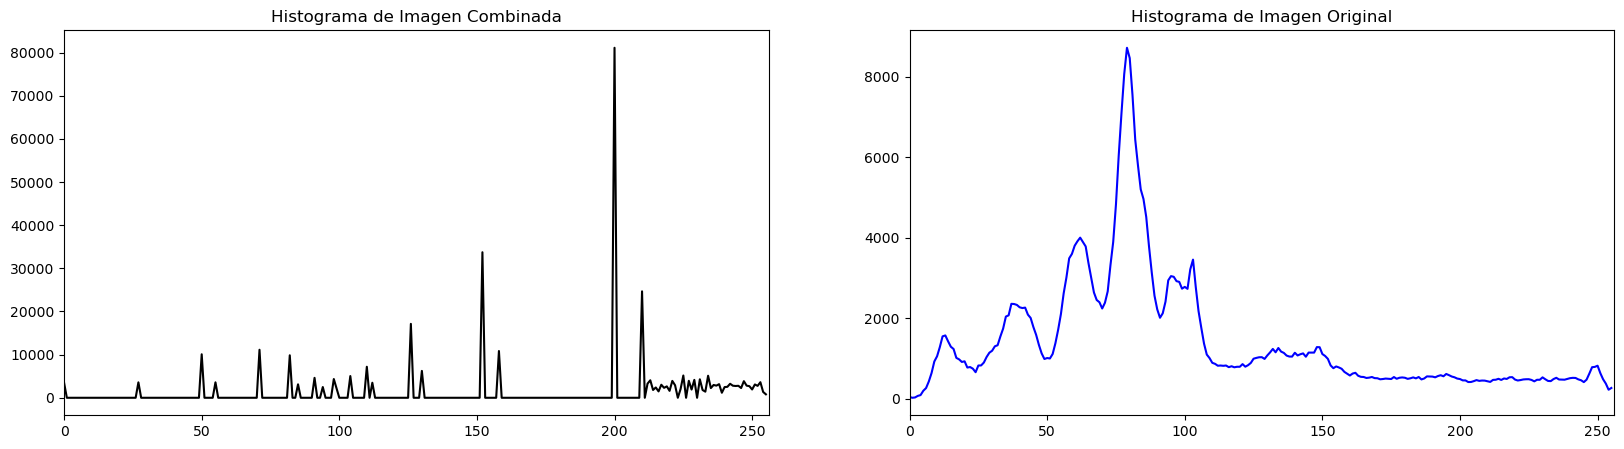

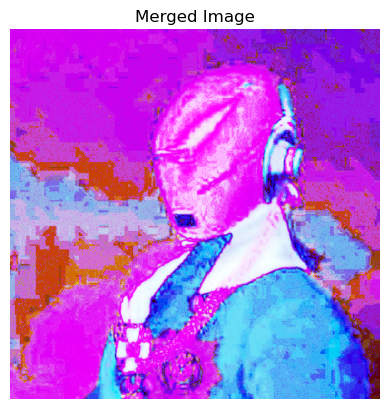

uint8
uint8
float32


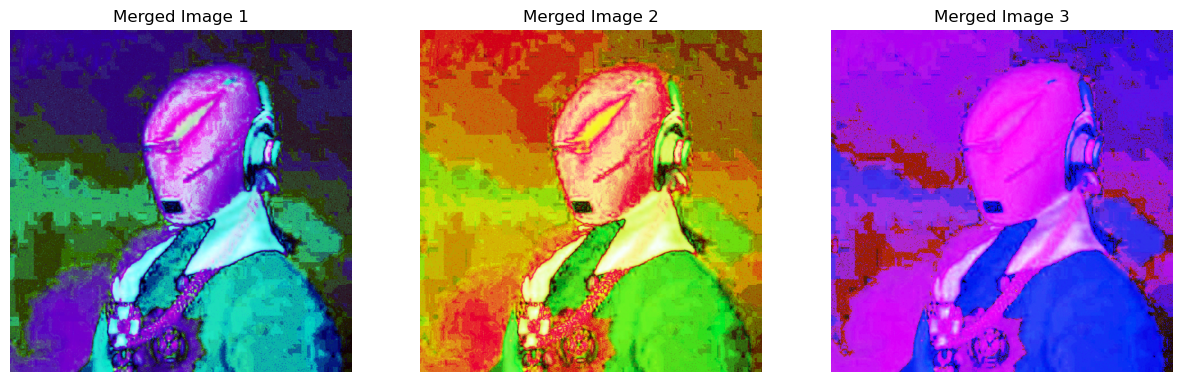

In [73]:
merged_image = cv2.merge([Red_Hulk, Green_Hulk, Blue_Hulk])
merged_image = cv2.normalize(merged_image, None, 0, 255, cv2.NORM_MINMAX)
hist_merged = cv2.calcHist([merged_image], [0], None, [256], [0, 256])
hist_img = cv2.calcHist([img], [0], None, [256], [0, 256])

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_merged, color='black')
plt.xlim([0, 256])
plt.title('Histograma de Imagen Combinada')
plt.subplot(1, 2, 2)
plt.plot(hist_img, color='blue')
plt.xlim([0, 256])
plt.title('Histograma de Imagen Original')
plt.show()


plt.imshow(merged_image)
plt.title('Merged Image')
plt.axis('off')
plt.show()

print(diff_R.dtype)
print(Green_Hulk.dtype)
print(hist_blue.dtype)



image1 = cv2.merge([diff_R, Green_Hulk, EQB_hulk])
image2 = cv2.merge([Red_Hulk, EQG_hulk, diff_B])
image3 = cv2.merge([EQR_hulk, diff_G, Blue_Hulk])

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image1)
plt.title('Merged Image 1')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(image2)
plt.title('Merged Image 2')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(image3)
plt.title('Merged Image 3')
plt.axis('off')
plt.show()


# Reconstrucciones
reconstruccion_R = cv2.merge([diff_R, Green_Hulk, np.zeros_like(Blue_Hulk)])




